In [2]:
import polars as pl
from plotnine import *

In [3]:
df = pl.read_csv('~/git/sandpiper/sra_metadata/sra_metadata_20250220.some_columns.csv.gz', has_header=False)
df.columns = ['acc','releasedate','mbases','mbytes']
df[:4]

acc,releasedate,mbases,mbytes
str,str,i64,i64
"""SRR15442735""","""2021-08-13T00:00:00+00:00""",6638,2614
"""ERR1959224""","""2017-07-08T00:00:00+00:00""",8555,3195
"""ERR5003368""","""2020-12-23T00:00:00+00:00""",1013,344
"""ERR5261058""","""2021-03-15T00:00:00+00:00""",20619,6792


In [4]:
df = df.with_columns(pl.col('releasedate').str.slice(0,10).str.to_date("%Y-%m-%d"))

In [5]:
# 15/11/2024 is when Josh started his stuff, so we need everything before that
df2 = df.filter(pl.col('releasedate') <= pl.date(2024,11,15))
df2.shape, df2[:4]

((716521, 4),
 shape: (4, 4)
 ┌─────────────┬─────────────┬────────┬────────┐
 │ acc         ┆ releasedate ┆ mbases ┆ mbytes │
 │ ---         ┆ ---         ┆ ---    ┆ ---    │
 │ str         ┆ date        ┆ i64    ┆ i64    │
 ╞═════════════╪═════════════╪════════╪════════╡
 │ SRR15442735 ┆ 2021-08-13  ┆ 6638   ┆ 2614   │
 │ ERR1959224  ┆ 2017-07-08  ┆ 8555   ┆ 3195   │
 │ ERR5003368  ┆ 2020-12-23  ┆ 1013   ┆ 344    │
 │ ERR5261058  ┆ 2021-03-15  ┆ 20619  ┆ 6792   │
 └─────────────┴─────────────┴────────┴────────┘)

# How big are the mbytes of the sra files?

/home/ben/e/mybase/lib/python3.11/site-packages/plotnine/layer.py:284: PlotnineWarning: stat_bin : Removed 640 rows containing non-finite values.


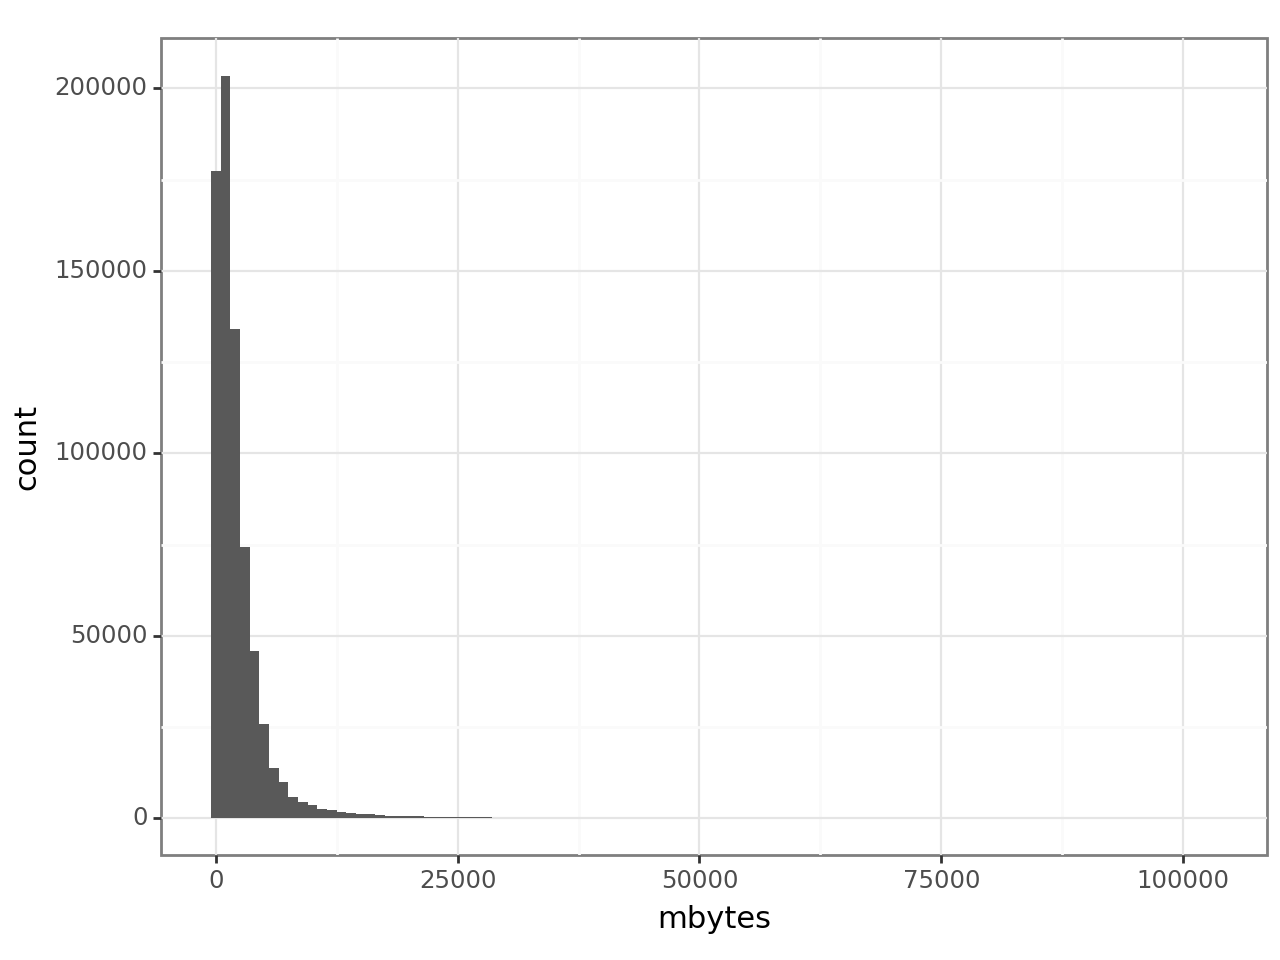

<Figure Size: (640 x 480)>

In [6]:
ggplot(df2.filter(pl.col('mbases')<2e6))+geom_histogram(aes(x='mbytes'), binwidth=1000)+theme_bw()

In [7]:
# df2.filter(pl.col('mbases')>200e3)
df2.sort('mbases', descending=True)[:4]

acc,releasedate,mbases,mbytes
str,date,i64,i64
"""ERR5029655""",2021-03-24,199584,59312
"""SRR31066179""",2024-10-22,198801,61494
"""ERR5029657""",2021-03-24,198000,59639
"""SRR22103702""",2023-10-18,195353,82242


In [8]:
df2.filter(pl.col('mbytes')>20000).shape[0] , df2.filter(pl.col('mbytes')>20000).shape[0] / df2.shape[0], df2.filter(pl.col('mbytes')>20000).select(pl.col('mbytes').sum()/1000)

(4952,
 0.006911172177786834,
 shape: (1, 1)
 ┌────────────┐
 │ mbytes     │
 │ ---        │
 │ f64        │
 ╞════════════╡
 │ 144006.042 │
 └────────────┘)

In [9]:
totals = []
for i in range(100):
    totals.append(df2.filter(pl.col('mbytes')<20000).sample(40).select(pl.col('mbytes').sum()/1000)[0,0])
pl.Series(totals).describe()

statistic,value
str,f64
"""count""",100.0
"""null_count""",0.0
"""mean""",83.45708
"""std""",13.120594
"""min""",51.832
"""25%""",74.106
"""50%""",82.521
"""75%""",91.549
"""max""",114.394


In [10]:
# df2.filter(pl.col('mbytes')<20000).select('acc').write_csv('acc_less_than_20k_mbytes.csv', include_header=False)